In [2]:
import numpy as np
import pandas
import dpluspy
import moments
import demes

In [3]:
import matplotlib, matplotlib.pylab as plt

plt.rcParams["legend.title_fontsize"] = "small"
matplotlib.rc("xtick", labelsize=9)
matplotlib.rc("ytick", labelsize=9)
matplotlib.rc("axes", labelsize=9)
matplotlib.rc("axes", titlesize=9)
matplotlib.rc("legend", fontsize=7)
plt.rcParams['legend.title_fontsize'] = 'small'

In [4]:
dfs = []

for rep in range(10):
    df = pandas.read_csv(f"results/ghost_den_fit_null_{rep}.csv")
    best_fit = df[df["ll"] == np.max(df["ll"])]
    best_fit = best_fit.assign(model=f"rep{rep}")
    dfs.append(best_fit)

for model in range(693):
    try:
        df = pandas.read_csv(f"results/ghost_den_fit_{model}.csv")
        best_fit = df[df["ll"] == np.max(df["ll"])]
        best_fit = best_fit.assign(model=model)
        dfs.append(best_fit)
    except:
        print(f"missing fit {model}")
df = pandas.concat(dfs)
df.to_csv("best_fits.csv", index=False)

missing fit 3
missing fit 4
missing fit 96
missing fit 101
missing fit 227
missing fit 228
missing fit 229
missing fit 231
missing fit 233
missing fit 234
missing fit 236
missing fit 241
missing fit 247
missing fit 255
missing fit 271
missing fit 275
missing fit 286
missing fit 302
missing fit 308
missing fit 371
missing fit 373
missing fit 457
missing fit 458
missing fit 460
missing fit 461
missing fit 474
missing fit 487
missing fit 498
missing fit 510
missing fit 531
missing fit 534
missing fit 535
missing fit 543
missing fit 555
missing fit 556
missing fit 567
missing fit 571
missing fit 599
missing fit 610
missing fit 626
missing fit 628
missing fit 641
missing fit 647
missing fit 651
missing fit 652
missing fit 667
missing fit 673
missing fit 682
missing fit 686
missing fit 688


In [5]:
df[np.isnan(df["T_Gho"])]

,ll,T_NDH,T_ND,T_AMH_Alt,p_AMH_Alt,N_Anc,N_Yor,N_ND,N_Den,N_Alt,m_AltDen,model,T_Gho,T_Gho_Den,p_Gho_Den,N_Gho
8,-31.784298,785609.567166,759592.018083,346107.649797,0.131572,16156.992322,27647.186545,992.169398,3460.273344,2248.349782,0.000008,rep0,NaN,NaN,NaN,NaN
4,-31.731639,785505.041312,763805.276226,347105.588954,0.131877,16158.846166,27644.880903,825.511968,3461.976522,2249.299230,0.000008,rep1,NaN,NaN,NaN,NaN
5,-32.530391,813481.443468,789668.320808,350309.634273,0.130313,15723.896022,28394.276471,897.301894,3447.133745,2237.811273,0.000008,rep2,NaN,NaN,NaN,NaN
6,-31.702639,788677.510333,769997.667522,347382.253396,0.131707,16108.930321,27728.178503,709.098723,3460.132389,2242.479933,0.000008,rep3,NaN,NaN,NaN,NaN
1,-31.711303,783344.857956,767383.267330,346538.654353,0.131950,16191.520348,27582.622889,606.161059,3462.549030,2241.654580,0.000008,rep4,NaN,NaN,NaN,NaN
8,-31.827017,790745.863970,759845.260163,348812.082086,0.132090,16079.441728,27789.606288,1179.202150,3450.757238,2253.497753,0.000008,rep5,NaN,NaN,NaN,NaN
5,-31.868446,781220.078105,754794.199144,346152.706199,0.132021,16224.466482,27527.323189,1009.022187,3462.155942,2252.999094,0.000008,rep6,NaN,NaN,NaN,NaN
0,-32.163597,805490.439483,766646.861397,349144.507839,0.130913,15848.766835,28185.059681,1484.850748,3429.666122,2238.653748,0.000008,rep7,NaN,NaN,NaN,NaN
0,-31.929533,773524.043822,764943.519092,346306.261647,0.133099,16343.603068,27309.639662,325.825905,3461.836714,2237.005727,0.000008,rep8,NaN,NaN,NaN,NaN
3,-31.756409,785856.910579,761688.754119,346808.993615,0.131743,16152.977366,27654.023495,920.678895,3460.380076,2248.851760,0.000008,rep9,NaN,NaN,NaN,NaN


In [6]:
df[df["ll"] == np.max(df["ll"])]

,ll,T_NDH,T_ND,T_AMH_Alt,p_AMH_Alt,N_Anc,N_Yor,N_ND,N_Den,N_Alt,m_AltDen,model,T_Gho,T_Gho_Den,p_Gho_Den,N_Gho
0,-30.663925,785243.072944,759366.504704,316971.677929,0.115678,16133.458507,27713.498718,965.840351,3429.616651,2279.549092,0.000006,387,3.978219e+06,91544.598607,0.000392,20196.484294


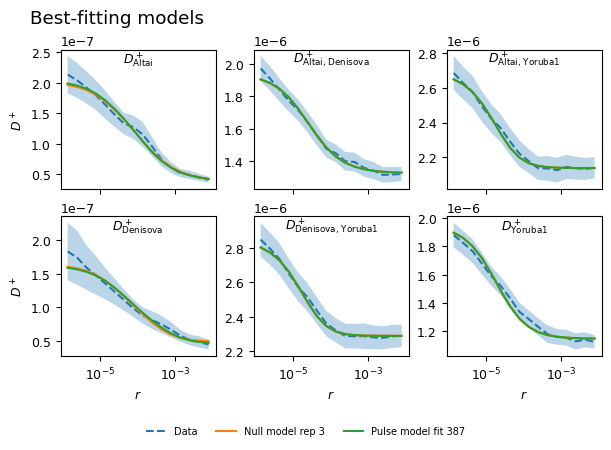

In [7]:
u = 1.3e-8
graph0 = "results/ghost_den_fit_null_3.yaml"
graph1 = "results/ghost_den_fit_387.yaml"
data_file = "../../../../analyses/recombination_maps/stats/subset_Bherer.pkl"
data = dpluspy.inference.load_stats(
    data_file, graph=graph0, return_dict=True)
model0 = dpluspy.inference.compute_bin_stats(graph0, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
model1 = dpluspy.inference.compute_bin_stats(graph1, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
dpluspy.plotting.plot_D_plus_curves(
    models=[model0, model1],
    pop_ids=data["pop_ids"], 
    bins=data["bins"], 
    means=data["means"], 
    varcovs=data["varcovs"], 
    labels=["Data", "Null model rep 3", "Pulse model fit 387"],
    title="Best-fitting models",
    out="figures/best_fit_model.pdf",
    cols=3
)